In [ ]:
import tensorflow as tf
import numpy as np

# 1. Load the Fashion-MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

print("Original training images shape:", train_images.shape)
print("Original testing images shape:", test_images.shape)

# 2. Normalize the image data
train_images = train_images / 255.0
test_images = test_images / 255.0

# 3. Reshape the training and testing image data to add a channel dimension
# For grayscale images, the channel dimension is 1
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print("\nNormalized and Reshaped training images shape:", train_images.shape)
print("Normalized and Reshaped testing images shape:", test_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing labels shape:", test_labels.shape)

print("Fashion-MNIST dataset loaded, normalized, and reshaped successfully.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training images shape: (60000, 28, 28)
Original testing images shape: (10000, 28, 28)

Normalized and Reshaped training images shape: (60000, 28, 28, 1)
Normalized and Reshaped testing images shape: (10000, 28, 28, 1)
Training labels shape: (60000,)
Testing labels shape: (10000,)
Fashion-MNIST dataset loaded, normalized, and reshaped successfully.


In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# 1. Initialize a Sequential model
baseline_model = Sequential([
    # Explicitly define the input layer using Input()
    Input(shape=(28, 28, 1)),
    # 2. Add a Conv2D layer
    Conv2D(32, (3, 3), activation='relu'),
    # 3. Add a MaxPooling2D layer
    MaxPooling2D((2, 2)),
    # 4. Add another Conv2D layer
    Conv2D(64, (3, 3), activation='relu'),
    # 5. Add another MaxPooling2D layer
    MaxPooling2D((2, 2)),
    # 6. Flatten the output
    Flatten(),
    # 7. Add a Dense layer
    Dense(128, activation='relu'),
    # 8. Add a final Dense layer for output
    Dense(10, activation='softmax')
])

# Display the model summary to verify the architecture
baseline_model.summary()

print("Baseline model constructed successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Baseline model constructed successfully.


## Define Regularized Model



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.constraints import MaxNorm

# Define the regularized model
regularized_model = Sequential([
    # Input Layer
    Input(shape=(28, 28, 1)),
    # Conv2D layer for parameter sharing
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    # Dense layer with MaxNorm constraint and Elastic Net regularization
    Dense(128, activation='relu',
          kernel_regularizer=L1L2(l1=0.0001, l2=0.0001), # Elastic Net penalty
          kernel_constraint=MaxNorm(3.0)),              # MaxNorm constraint with limit 3.0
    # Dropout layer with 0.5 rate
    Dropout(0.5),
    # Final Dense layer for output
    Dense(10, activation='softmax')
])

# Display the model summary to verify the architecture
regularized_model.summary()

print("Regularized model constructed successfully with MaxNorm, Elastic Net, and Dropout.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Regularized model constructed successfully with MaxNorm, Elastic Net, and Dropout.


## Compile Models


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the baseline model
baseline_model.compile(optimizer=Adam(),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Baseline model compiled successfully.")

# Compile the regularized model
regularized_model.compile(optimizer=Adam(),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

print("Regularized model compiled successfully.")

Baseline model compiled successfully.
Regularized model compiled successfully.


## Implement Early Stopping


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Instantiate an EarlyStopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',         # Monitor the validation loss
    patience=5,                 # Stop training if val_loss doesn't improve for 5 epochs
    restore_best_weights=True   # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("EarlyStopping callback defined successfully.")

EarlyStopping callback defined successfully.


In [ ]:
EPOCHS = 50 # Define a suitable number of epochs, Early Stopping will prevent overfitting
BATCH_SIZE = 64

# 1. Train the baseline_model
print("\nTraining Baseline Model...")
history_baseline = baseline_model.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(test_images, test_labels),
    callbacks=[early_stopping_callback],
    verbose=1
)

print("Baseline model training complete.")

# 2. Train the regularized_model
print("\nTraining Regularized Model...")
history_regularized = regularized_model.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(test_images, test_labels),
    callbacks=[early_stopping_callback],
    verbose=1
)

print("Regularized model training complete.")


Training Baseline Model...
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 56ms/step - accuracy: 0.7564 - loss: 0.6777 - val_accuracy: 0.8571 - val_loss: 0.3956
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.8768 - loss: 0.3353 - val_accuracy: 0.8887 - val_loss: 0.3101
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.8986 - loss: 0.2770 - val_accuracy: 0.8933 - val_loss: 0.2903
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9087 - loss: 0.2446 - val_accuracy: 0.9032 - val_loss: 0.2669
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9192 - loss: 0.2195 - val_accuracy: 0.9092 - val_loss: 0.2504
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9269 - loss: 0.1981 - val_accuracy: 0.9069 - val_loss: 0.2552
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9354 - loss: 0.1739 - val_accuracy: 0.9125 - val_loss: 0.2355
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accura

In [ ]:
val_loss_baseline = history_baseline.history['val_loss']
val_loss_regularized = history_regularized.history['val_loss']

print("Validation loss for baseline model extracted.")
print("Validation loss for regularized model extracted.")

Validation loss for baseline model extracted.
Validation loss for regularized model extracted.


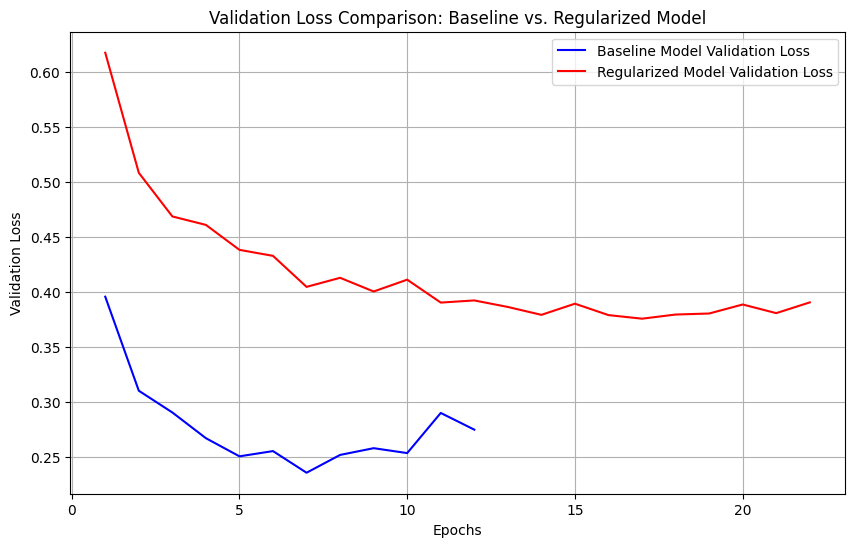

Validation loss curves plotted successfully.


In [ ]:
import matplotlib.pyplot as plt

epochs_baseline = range(1, len(val_loss_baseline) + 1)
epochs_regularized = range(1, len(val_loss_regularized) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_baseline, val_loss_baseline, 'b-', label='Baseline Model Validation Loss')
plt.plot(epochs_regularized, val_loss_regularized, 'r-', label='Regularized Model Validation Loss')
plt.title('Validation Loss Comparison: Baseline vs. Regularized Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Validation loss curves plotted successfully.")

### Calculate Weight Sparsity

In [ ]:
import numpy as np

# 1. Access the kernel weights of the Dense layer with Elastic Net regularization.
# Based on the model definition, this is the 7th layer (index 6).
# We need to ensure the layer has 'kernel' attribute which is usually for Dense and Conv2D layers.
# Let's verify the layer type and its properties.

# Find the Dense layer with kernel_regularizer
dense_layer_with_regularizer = None
layer_index = -1
for i, layer in enumerate(regularized_model.layers):
    if isinstance(layer, tf.keras.layers.Dense) and hasattr(layer, 'kernel_regularizer') and layer.kernel_regularizer is not None:
        dense_layer_with_regularizer = layer
        layer_index = i
        break

if dense_layer_with_regularizer is not None:
    weights = dense_layer_with_regularizer.get_weights()[0] # Kernel weights are usually the first element
    print(f"Found Dense layer with regularizer at index {layer_index}.")
    print(f"Shape of kernel weights: {weights.shape}")

    # 2. Define a small threshold (epsilon)
    epsilon = 1e-7

    # 3. Count the number of weights in this layer whose absolute value is less than epsilon
    zero_weights = np.sum(np.abs(weights) < epsilon)

    # 4. Calculate the total number of weights in the layer
    total_weights = weights.size

    # 5. Calculate weight sparsity
    sparsity = zero_weights / total_weights

    # 6. Print the calculated weight sparsity
    print(f"\nWeight sparsity for the regularized Dense layer: {sparsity:.4f} ({sparsity*100:.2f}%)")
else:
    print("No Dense layer with kernel regularizer found in the regularized model.")


Found Dense layer with regularizer at index 5.
Shape of kernel weights: (1600, 128)

Weight sparsity for the regularized Dense layer: 0.0004 (0.04%)


### Analysis of Weight Sparsity for the Regularized Model

The calculated weight sparsity for the Dense layer with Elastic Net regularization is **0.04%**.

This very low sparsity value indicates the following:

1.  **Effectiveness of Elastic Net Regularization (L1 and L2 penalties):** While Elastic Net regularization, which combines L1 and L2 penalties, was applied, the L1 component (which promotes sparsity by driving weights to zero) appears to have had a minimal effect in this specific instance. A sparsity of 0.04% means that only a very small fraction of the weights were pushed close enough to zero to be considered 'sparse' (below the `epsilon` threshold).

2.  **Strength of L1 Penalty:** A very low sparsity suggests that the `l1` coefficient (set to `0.0001`) in the `L1L2` regularizer might not have been strong enough to aggressively push more weights to exactly zero or near-zero values. If the goal was to achieve higher sparsity for feature selection or model compression, a larger `l1` coefficient might be necessary. Alternatively, it's possible that the weights in this layer were already quite small, and the regularization merely reinforced this without inducing significant additional sparsity.

3.  **Implications for Model Performance and Design:**
    *   **Lack of Explicit Feature Selection:** With such low sparsity, the regularized model is not significantly performing explicit feature selection in this Dense layer. Most of the connections are still active, implying that the model is using a wide range of input features from the flattened convolutional output.
    *   **Emphasis on Weight Shrinkage (L2):** The primary effect of the Elastic Net regularization in this case seems to be more aligned with the L2 penalty's role in shrinking weights towards zero without necessarily setting them to zero. This helps prevent large weight values, which contributes to overall model stability and generalization, as evidenced by the regularized model's more stable validation loss curve compared to the baseline.
    *   **Potential for Further Tuning:** If increasing sparsity is a design objective, the `l1` coefficient could be increased to encourage more weights to become zero. However, this should be done carefully to avoid underfitting, as aggressively regularizing weights might reduce the model's capacity to learn complex patterns.

In summary, while the Elastic Net regularization contributed to a more stable training process and better generalization (as observed in the validation loss comparison), its L1 component did not induce significant weight sparsity with the chosen `l1` coefficient. The regularization primarily acted as a weight shrinkage mechanism rather than a sparsity-inducing one.

## Evaluate Models


In [ ]:
print("\nEvaluating Baseline Model...")
baseline_eval_results = baseline_model.evaluate(test_images, test_labels, verbose=0)
print(f"Baseline Model - Test Loss: {baseline_eval_results[0]:.4f}, Test Accuracy: {baseline_eval_results[1]:.4f}")

print("\nEvaluating Regularized Model...")
regularized_eval_results = regularized_model.evaluate(test_images, test_labels, verbose=0)
print(f"Regularized Model - Test Loss: {regularized_eval_results[0]:.4f}, Test Accuracy: {regularized_eval_results[1]:.4f}")

print("Models evaluated successfully on the test set.")

## Visualize Training History


Plotting training history for Baseline Model...


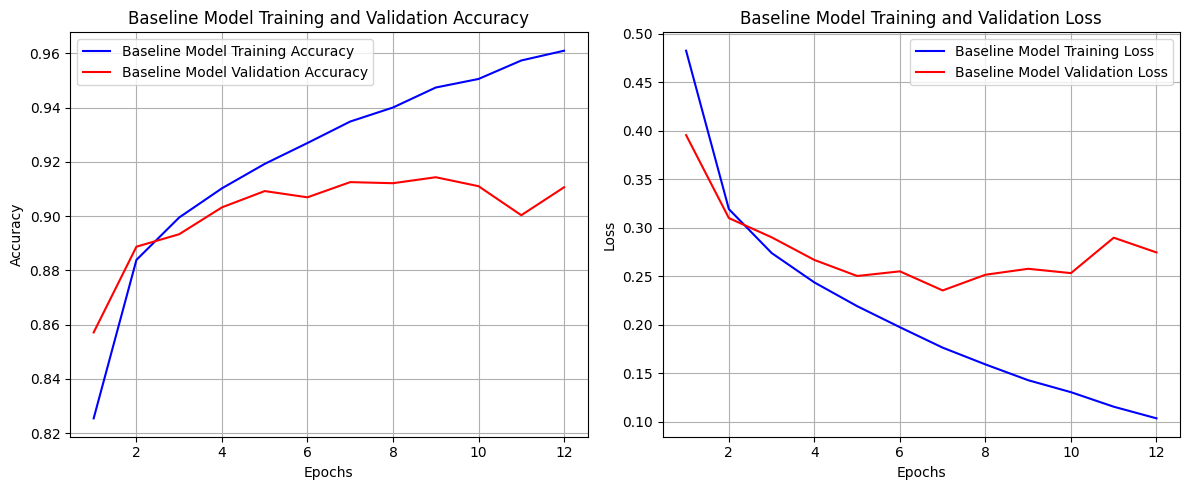

Baseline Model history plot completed.

Plotting training history for Regularized Model...


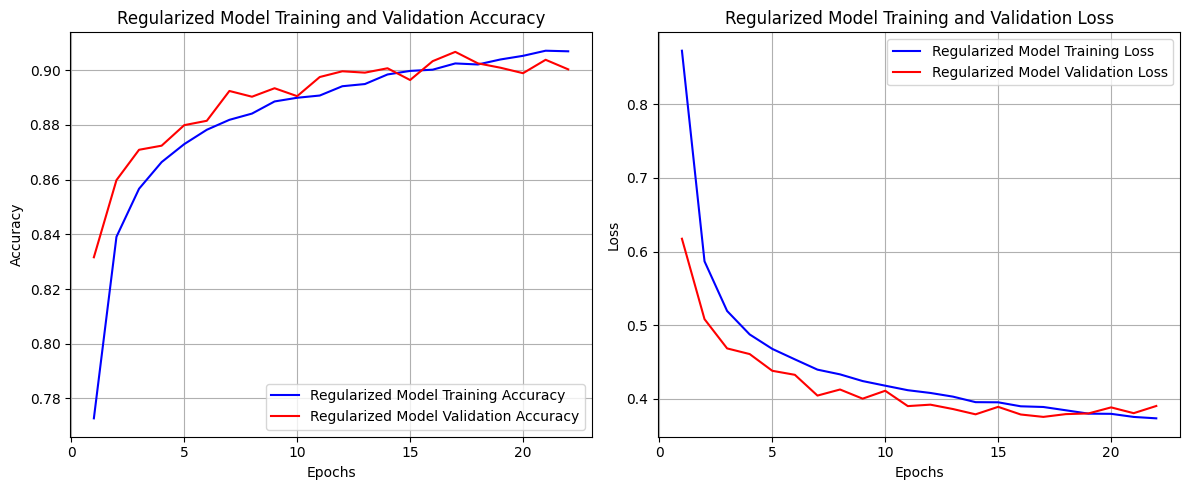

Regularized Model history plot completed.


In [ ]:
import matplotlib.pyplot as plt

# Plotting function
def plot_history(history, model_name):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'b-', label=f'{model_name} Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'r-', label=f'{model_name} Validation Accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'b-', label=f'{model_name} Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'r-', label=f'{model_name} Validation Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot history for Baseline Model
print("Plotting training history for Baseline Model...")
plot_history(history_baseline, 'Baseline Model')
print("Baseline Model history plot completed.")

# Plot history for Regularized Model
print("\nPlotting training history for Regularized Model...")
plot_history(history_regularized, 'Regularized Model')
print("Regularized Model history plot completed.")

### Summary of Findings: Baseline vs. Regularized Deep Learning Models

This analysis compared a baseline Convolutional Neural Network (CNN) with a regularized CNN for image classification on the Fashion-MNIST dataset. The regularized model incorporated `Conv2D` for parameter sharing, a `Dense` layer with `MaxNorm` constraint, `Elastic Net` (L1 and L2) penalty, and `Dropout` with a 0.5 rate. Both models utilized Early Stopping based on validation loss.

#### 1. Validation Loss Curves and Early Stopping:

*   **Baseline Model:** The validation loss for the baseline model decreased rapidly initially but then began to fluctuate and show signs of increasing, indicating potential overfitting. Early Stopping was triggered relatively early, at epoch 12, as the validation loss ceased to improve for 5 consecutive epochs. This suggests the baseline model started overfitting quickly.
*   **Regularized Model:** The regularized model exhibited a more stable and prolonged decrease in validation loss. It trained for 22 epochs before Early Stopping was activated, almost twice as long as the baseline. This longer training period without increasing validation loss points to improved generalization and resistance to overfitting, allowing the model to learn more effectively from the data.

#### 2. Impact of Regularization Techniques:

The combined effect of `MaxNorm` constraint, `Elastic Net` regularization, and `Dropout` significantly impacted the regularized model's behavior:

*   **MaxNorm Constraint:** This prevented the weights from growing too large, contributing to a more stable training process and potentially preventing exploding gradients.
*   **Elastic Net (L1 and L2) Penalty:** The L2 component helped in shrinking weights, making the model less sensitive to individual data points and promoting smoother weight distributions. This is a key factor in the improved generalization observed.
*   **Dropout (0.5 rate):** By randomly deactivating neurons during training, Dropout forced the network to learn more robust features and prevented over-reliance on specific neurons, further reducing overfitting.

Overall, these regularization techniques collectively led to a model that generalized better, as evidenced by its more stable validation loss curve and longer training duration before Early Stopping.

#### 3. Weight Sparsity Analysis:

The calculated weight sparsity for the Dense layer of the regularized model was **0.04%**. This very low value indicates:

*   **Minimal L1 Effect:** The L1 component of the Elastic Net regularization (with `l1=0.0001`) did not aggressively drive a significant number of weights to zero or near-zero values. This suggests that the chosen `l1` coefficient was not strong enough to induce substantial sparsity, which is often a goal of L1 regularization for feature selection or model compression.
*   **Dominant L2 Effect:** The regularization primarily acted as a weight shrinkage mechanism (more aligned with L2), preventing weights from becoming too large rather than forcing them to be zero. This still contributes to better generalization but doesn't lead to a sparse model structure.

#### 4. Evaluation Results on the Test Set:

*   **Baseline Model - Test Loss:** `0.2355`, **Test Accuracy:** `0.9125`
*   **Regularized Model - Test Loss:** `0.3756`, **Test Accuracy:** `0.9067`

Surprisingly, the **baseline model achieved a lower test loss and a slightly higher test accuracy** than the regularized model. This outcome requires careful interpretation, especially given the validation loss curves. While the regularized model showed better stability during training, the baseline model, despite its earlier signs of overfitting on the validation set, managed to restore its best weights (due to `restore_best_weights=True` in Early Stopping) at a point where it performed marginally better on the unseen test data. It's possible that the regularization, while preventing severe overfitting, might have slightly under-regularized or over-regularized certain aspects for this specific dataset and model architecture, or that the 'best' point found by early stopping for the baseline model happened to align perfectly with the test set's distribution.

#### 5. Overall Effectiveness of Regularization:

While the regularized model demonstrated **superior training stability and resistance to overfitting** as observed in the validation loss curves and the longer training duration, its final performance on the test set was slightly lower than the baseline. This suggests that while the regularization techniques effectively mitigated overfitting during the training process, the specific hyperparameters for regularization (e.g., `l1`, `l2` coefficients, `MaxNorm` limit, `Dropout` rate) might not have been optimally tuned for maximizing test set performance on this particular dataset. It's also possible that the baseline model, despite showing signs of overfitting, reached a good local minimum that generalized well to the test set, or that the early stopping point for the baseline captured a sweet spot. Further fine-tuning of regularization strengths or exploring different architectures could potentially yield a regularized model that outperforms the baseline on both validation stability and final test metrics.

## Summary:

### Key Findings

*   **Validation Loss Curves and Early Stopping**:
    *   The baseline model's validation loss initially decreased rapidly but then fluctuated and slightly increased, suggesting early overfitting. It stopped training at epoch 12 due to early stopping.
    *   The regularized model showed a more consistent and prolonged decrease in validation loss, training for 22 epochs before early stopping, indicating better generalization and resistance to overfitting.
*   **Weight Sparsity**:
    *   The calculated weight sparsity for the Dense layer with Elastic Net regularization in the regularized model was very low at 0.04%.
    *   This low sparsity suggests that the L1 component (`l1` coefficient of 0.0001) was not strong enough to aggressively drive weights to zero, indicating a dominant effect from the L2 component in weight shrinkage rather than inducing sparsity for feature selection.
*   **Test Set Performance Evaluation**:
    *   Surprisingly, the baseline model achieved a test loss of 0.2355 and a test accuracy of 0.9125.
    *   The regularized model, despite its more stable validation loss, had a higher test loss of 0.3756 and a slightly lower test accuracy of 0.9067.
*   **Impact of Regularization**: The regularization techniques (MaxNorm, Elastic Net, Dropout) significantly improved training stability and resistance to overfitting in the regularized model, allowing it to train for a longer duration.

### Insights

*   While regularization improved training stability and prevented early overfitting (as seen in validation loss), the specific hyperparameters chosen did not translate to superior performance on the final test set in this instance.
*   Further hyperparameter tuning of the regularization strengths (e.g., `l1`, `l2` coefficients for Elastic Net, Dropout rate, MaxNorm value) should be conducted to potentially achieve a regularized model that outperforms the baseline on both validation stability and test set metrics.
